In [ ]:
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.drivers import PySCFDriver


print("=" * 60)
print("VQE for LiH Molecule on simulator")
print("=" * 60)

# ---- Step 1: Generate LiH Hamiltonian ----
print("\n[1/5] Generating LiH Hamiltonian...")
driver = PySCFDriver(atom='Li 0 0 0; H 0 0 1.6', basis='sto3g')
problem = driver.run()
mapper = JordanWignerMapper()
hamiltonian = mapper.map(problem.hamiltonian.second_q_op())

print(f"  ✓ Number of qubits: {hamiltonian.num_qubits}")
print(f"  ✓ Number of Pauli terms: {len(hamiltonian)}")

VQE for LiH Molecule on simulator

[1/5] Generating N2 Hamiltonian...
  ✓ Number of qubits: 12
  ✓ Number of Pauli terms: 631


In [2]:
expected_energy = -7.88232437888349 #Ha
print(f"Expected total energy (including nuclear repulsion): {expected_energy} Ha")

Expected total energy (including nuclear repulsion): -7.88232437888349 Ha


This circuit has  24 parameters


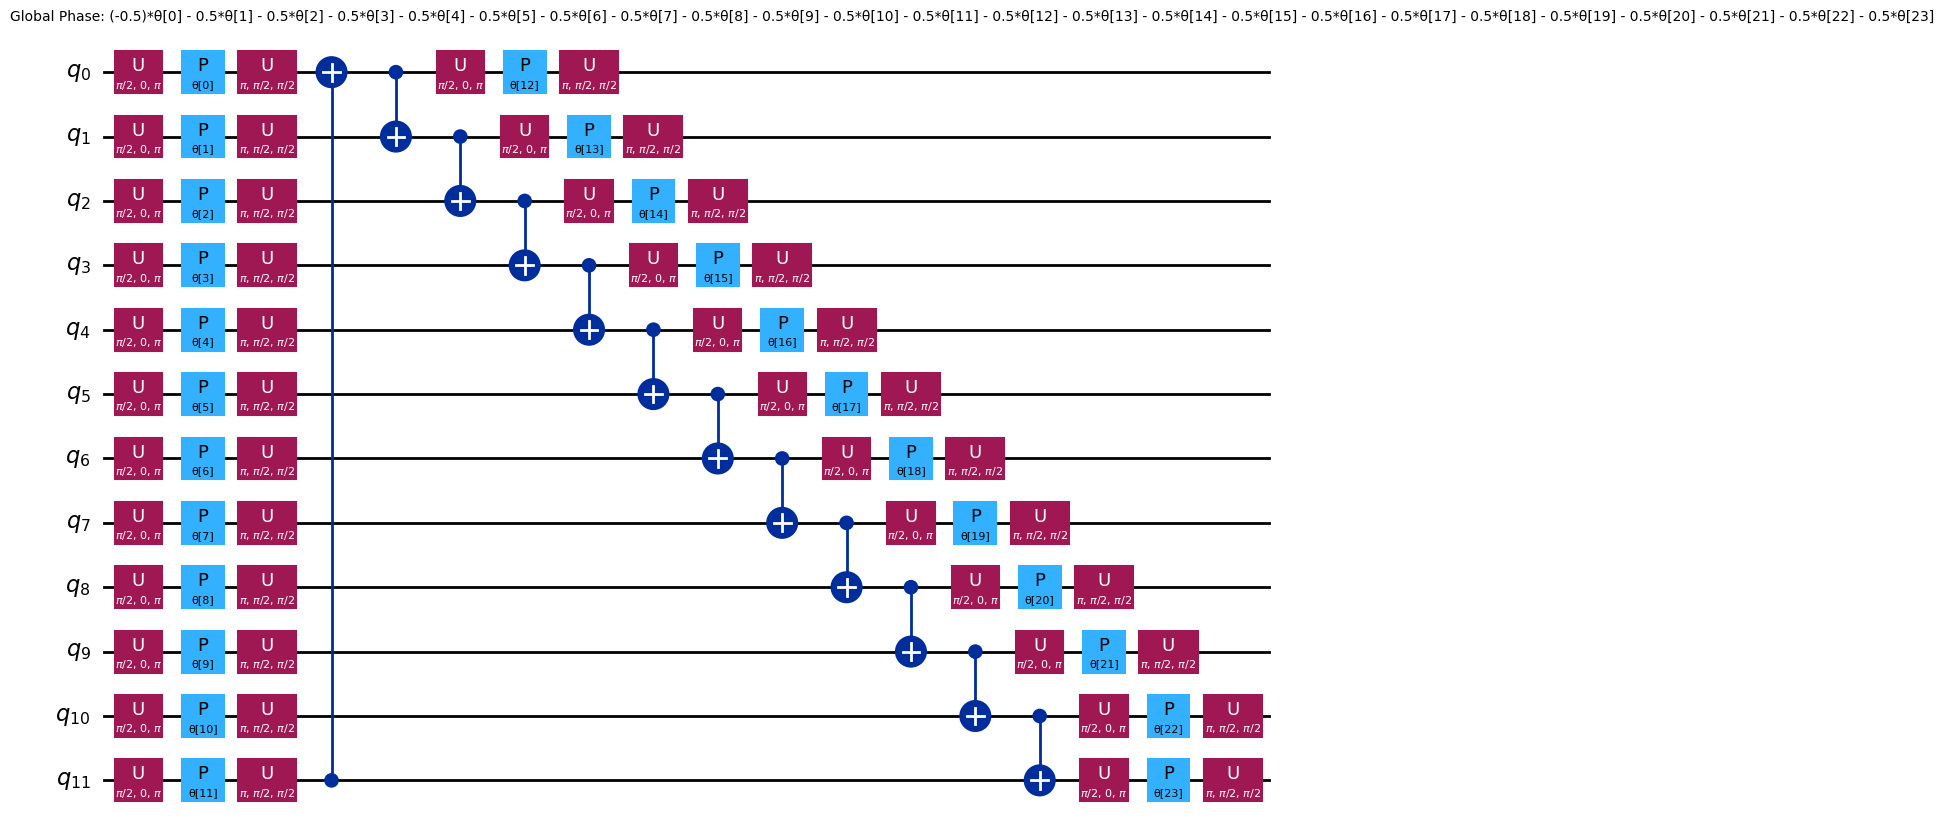

In [3]:
# Pre-defined ansatz circuit and operator class for Hamiltonian
from qiskit.circuit.library import efficient_su2
 
# Note that it is more common to place initial 'h' gates outside the ansatz. Here we specifically wanted this layer structure.
ansatz = efficient_su2(
    hamiltonian.num_qubits, su2_gates=["h", "rz", "y"], entanglement="circular", reps=1
)
num_params = ansatz.num_parameters
print("This circuit has ", num_params, "parameters")
 
ansatz.decompose().draw("mpl", style="iqp")

In [ ]:
from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    Session,
    EstimatorV2 as Estimator,
)
 
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False)


from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=3
)



pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_ansatz = pm.run(ansatz)
isa_hamiltonian = hamiltonian.apply_layout(isa_ansatz.layout)

iterations = [0]  # Mutable object to track iterations
def cost_function(params, ansatz, estimator):
    iterations[0] += 1
    print(f"Iteration {iterations[0]}")

    bound = ansatz.assign_parameters(params)

    job = estimator.run([(bound, isa_hamiltonian)])
    result = job.result()
    electronic = result[0].data.evs
    complete_energy = electronic + problem.nuclear_repulsion_energy
    print(f"  Energy: {complete_energy:.6f} Ha")


    return complete_energy

In [9]:
print("Depth:", isa_ansatz.depth())
print("2q gates:", isa_ansatz.num_nonlocal_gates())
print("Pauli terms:", len(isa_hamiltonian.paulis))

Depth: 58
2q gates: 12
Pauli terms: 631


In [ ]:
from scipy.optimize import minimize
import numpy as np

initial_params = np.zeros(num_params)

with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 8192    
    print(f"\nStarting optimization\n")
    
    result = minimize(
        cost_function,
        initial_params,
        method="COBYLA",  # Derivative-free optimizer
        args=(isa_ansatz, estimator),
        options={
            "maxiter": 35,      # Maximum iterations
            "tol": 1e-5         # Convergence tolerance
        }
    )


Starting optimization

Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
